In [1]:
import app
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, lit
import time



In [2]:
spark = SparkSession.builder.appName("LoadSearchAlgorithm").getOrCreate()

posting_data = spark.read.csv("./load_posting.csv", header=True, inferSchema=True)
stop_data = spark.read.csv("./load_stop.csv", header=True, inferSchema=True)



In [3]:
specific_loads = app.testing("Power Only", 400, 40000, posting_data, stop_data, "TX", "TX")

+-----------+--------------+
|    LOAD_ID|max(is_origin)|
+-----------+--------------+
|ST172888725|          true|
|ST172888142|          true|
| 4005865373|          true|
|ST172869597|          true|
|ST172821603|          true|
|ST172871493|          true|
|ST172898200|          true|
|ST172932610|          true|
|ST172934262|          true|
| 4005940208|          true|
|ST172931113|          true|
|ST172929644|          true|
|ST172910171|          true|
| 4005944773|          true|
|ST172888463|          true|
| 4005923876|          true|
|ST172863018|          true|
|ST172871474|          true|
|ST172871135|          true|
|ST172876170|          true|
+-----------+--------------+
only showing top 20 rows

['ST172888725', 'ST172888142', '4005865373', 'ST172869597', 'ST172821603', 'ST172871493', 'ST172898200', 'ST172932610', 'ST172934262', '4005940208', 'ST172931113', 'ST172929644', 'ST172910171', '4005944773', 'ST172888463', '4005923876', 'ST172863018', 'ST172871474', 'ST17287113

In [4]:
target_load_id = 'ST172888725'
stops_for_load = stop_data.filter(col("LOAD_ID") == target_load_id)
stops_for_load.show()

+----+-----------+---------+-------------+---------+-------------+-------------------+-------------------+-------------+-----+-----------+----------+-------+--------------------+--------------------+-----------------+
| _c0|    LOAD_ID|  STOP_ID|STOP_SEQUENCE|STOP_TYPE|ACTIVITY_TYPE|   APPOINTMENT_FROM|     APPOINTMENT_TO|         CITY|STATE|POSTAL_CODE| TIME_ZONE|COUNTRY|        CREATED_DATE|        UPDATED_DATE|APPOINTMENT_STATE|
+----+-----------+---------+-------------+---------+-------------+-------------------+-------------------+-------------+-----+-----------+----------+-------+--------------------+--------------------+-----------------+
|3717|ST172888725|366137209|            1|        P|         NULL|2024-10-04 15:00:00|2024-10-04 18:00:00|Grand Prairie|   TX|      75050|US/Central|    USA|2024-09-26 20:46:...|2024-09-26 20:46:...|                A|
|3718|ST172888725|366137210|            2|        D|         NULL|2024-10-04 16:00:00|2024-10-04 23:00:00|      Sherman|   TX|  

In [5]:
import pcmiller

routes = []

for load in specific_loads:
    stops_for_load = stop_data.filter(col("LOAD_ID") == load)
    spec_data = stops_for_load.collect()
    stops = []
    for s in spec_data:
        stops.append({
            "Address": {
                "Zip": s["POSTAL_CODE"]  # Assuming stop dict contains 'Zip' key
            },
            "Label": s["CITY"]  # Assuming stop dict contains 'Label' key
        })
    ret = pcmiller.requestHelper(stops)
    routes.append(ret)
    break



In [6]:
for i in range(len(routes)):
    stops = []
    for stop in routes[i][0]["ReportLines"]:
        stops.append(stop["Stop"]["Coords"])
    x = pcmiller.routeCalc(stops)
    print(x)
        
    
    


{'type': 'Feature', 'geometry': {'type': 'MultiLineString', 'coordinates': [[[-96.991888, 32.748124], [-96.992343, 32.748122], [-96.992346, 32.748507], [-96.992349, 32.74877], [-96.993227, 32.748776], [-96.993917, 32.748781], [-96.994644, 32.748754], [-96.99467, 32.749471], [-96.994677, 32.749897], [-96.994665, 32.750439], [-96.99467, 32.750833], [-96.994686, 32.751455], [-96.994681, 32.751747], [-96.994728, 32.752556], [-96.99475, 32.752928], [-96.994763, 32.753223], [-96.994802, 32.753709], [-96.994836, 32.754278], [-96.994877, 32.754951], [-96.994896, 32.755626], [-96.994959, 32.75781], [-96.994965, 32.758178], [-96.994348, 32.758154], [-96.990543, 32.758166], [-96.988764, 32.75823], [-96.987842, 32.758349], [-96.98692, 32.758496], [-96.985598, 32.758596], [-96.985036, 32.758723], [-96.978552, 32.759093], [-96.976281, 32.759238], [-96.975185, 32.759339], [-96.974569, 32.759365], [-96.973951, 32.759423], [-96.972729, 32.759601], [-96.970961, 32.759992], [-96.96787, 32.760975], [-96.9

[{'City': 'Grand Prairie', 'State': 'TX', 'Zip': '75050'}, {'City': 'Sherman', 'State': 'TX', 'Zip': '75092'}]
HELLO


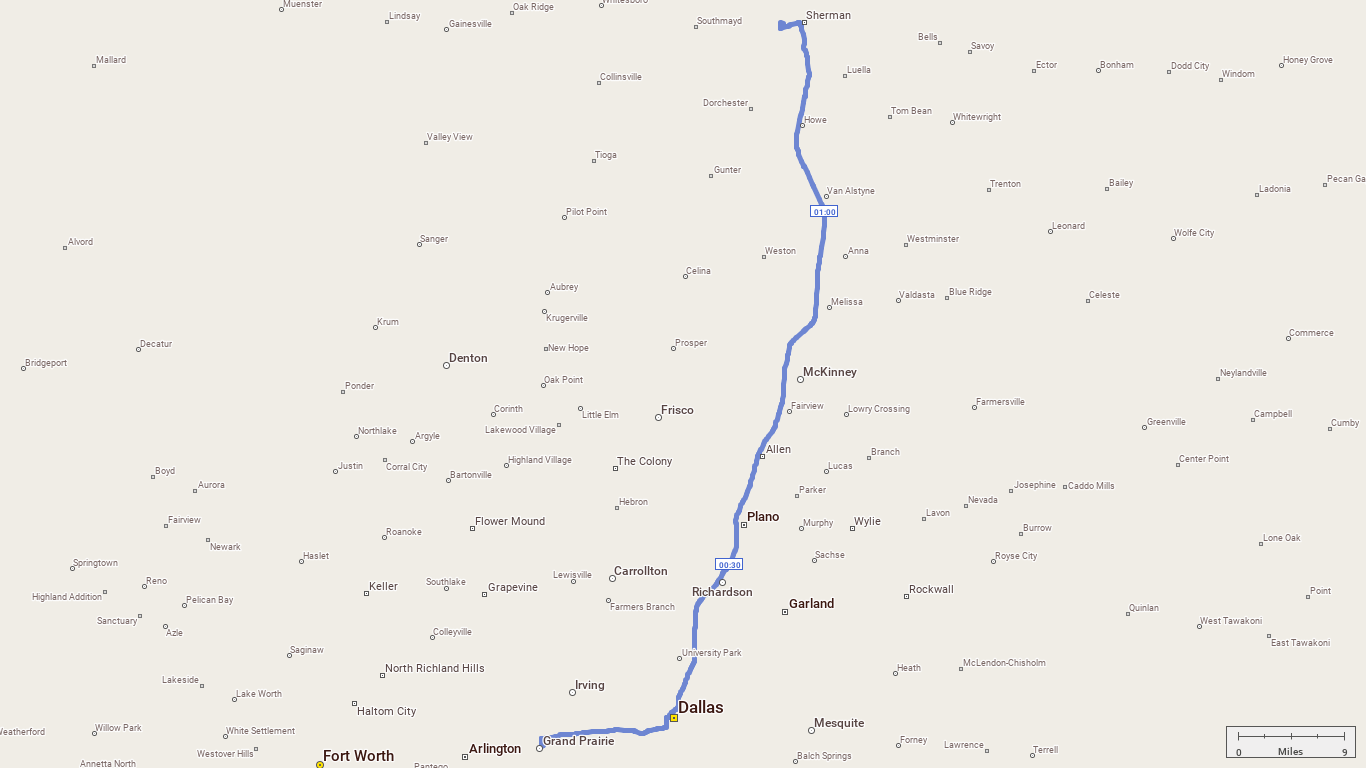

In [7]:
for load in specific_loads:
    stops_for_load = stop_data.filter(col("LOAD_ID") == load)
    spec_data = stops_for_load.collect()
    stops = []
    for s in spec_data:
        stops.append({
            "City": s["CITY"],
            "State": s["STATE"],
            "Zip": s["POSTAL_CODE"], # Assuming stop dict contains 'Label' key
        })
    print(stops)
    ret = pcmiller.mapGenerator(stops)
    routes.append(ret)
    break
    
ret

In [8]:
specific_loads = app.searchAlgo("Power Only", 400, 40000, "TX", "TX")

+-----------+--------------+
|    LOAD_ID|max(is_origin)|
+-----------+--------------+
|ST172888725|          true|
|ST172888142|          true|
| 4005865373|          true|
|ST172869597|          true|
|ST172821603|          true|
|ST172871493|          true|
|ST172898200|          true|
|ST172932610|          true|
|ST172934262|          true|
| 4005940208|          true|
|ST172931113|          true|
|ST172929644|          true|
|ST172910171|          true|
| 4005944773|          true|
|ST172888463|          true|
| 4005923876|          true|
|ST172863018|          true|
|ST172871474|          true|
|ST172871135|          true|
|ST172876170|          true|
+-----------+--------------+
only showing top 20 rows

['ST172888725', 'ST172888142', '4005865373', 'ST172869597', 'ST172821603', 'ST172871493', 'ST172898200', 'ST172932610', 'ST172934262', '4005940208', 'ST172931113', 'ST172929644', 'ST172910171', '4005944773', 'ST172888463', '4005923876', 'ST172863018', 'ST172871474', 'ST17287113

In [9]:
ret = pcmiller.getCoords(53703)

Error: 403 
